# Comparison of in vitro differentiation with in vivo embryos

In [1]:
here::i_am("rna_atac/clustering/05_vitro_vivo_comparison.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”


In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

# Archr
args$archr_directory = file.path(io$basedir, 'processed/atac/archR')

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/celltype_markers/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
# Load meta
meta = fread(args$metadata) %>% 
    .[genotype=='WT']  # Only WT cells for celltype marker search

In [4]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

#### Atlas

In [7]:
# Load cell metadata
meta_atlas <- fread('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata_extended.txt.gz') %>%
  .[,sample:=factor(sample)] 

In [8]:
# Update cell-types --> only change ExE mesoderm to LPM for this comparison
meta_atlas = meta_atlas[,celltype_updated := celltype] %>% 
    # Change 'ExE mesoderm' to 'Lateral plate mesoderm'
    .[,celltype_updated := ifelse(celltype_updated == 'ExE_mesoderm', 'Lateral_plate_mesoderm', celltype_updated)]

In [9]:
# # Keep only celltypes of interest
# celltypes_keep = c('Primitive_Streak', 
#          'Nascent_mesoderm',
#          'Mixed_mesoderm',
#          'Lateral_plate_mesoderm', 
#          'Intermediate_mesoderm',
#          'Haematoendothelial_progenitors',
#          'Blood_progenitors_1',
#          'Endothelium',
#          'Allantois', 
#          'Mesenchyme' 
#          )
celltypes_keep = meta_atlas$celltype_updated
meta_atlas = meta_atlas[celltype_updated %in% celltypes_keep]
## For now first try with every cell-type

In [10]:
# Load Atlas
atlas.sce = load_SingleCellExperiment(io$rna.atlas.sce, cells = meta_atlas$cell, normalise = TRUE)

# Get gene metadata
gene_metadata <- fread(io$gene_metadata) %>% .[,c("chr","ens_id","symbol")] %>%
  .[symbol!="" & !is.na(symbol) & ens_id %in% rownames(atlas.sce)] %>%
  .[!duplicated(symbol)]

atlas.sce = atlas.sce[gene_metadata$ens_id]
rownames(atlas.sce) = gene_metadata[match(rownames(atlas.sce), ens_id), symbol]

In [11]:
colData(atlas.sce) = meta_atlas %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

# Convert to Seurat
#atlas.seurat = as.Seurat(atlas.sce)

In [12]:
celltypes_test = celltypes_keep = c('Primitive_Streak', 
         'Nascent_mesoderm',
         'Mixed_mesoderm',
         'Lateral_plate_mesoderm', 
         'Intermediate_mesoderm',
         'Haematoendothelial_progenitors',
         'Blood_progenitors_1',
         'Endothelium',
         'Allantois', 
         'Mesenchyme' 
         )

In [13]:
markers = readRDS(file.path(args$outdir, 'Atlas_markers_edgeR.rds')) %>% rbindlist()

In [122]:
marker_scores = mclapply(celltypes_test, function(x){
    tmp.sce = atlas.sce[,atlas.sce$celltype_updated==x]
    score.dt = lapply(unique(markers$celltype), function(y){
            genes = head(markers[celltype==y & FDR < 0.05][order(-logFC)], 100) %>% .$gene
            tmp = data.table(celltype = x,
                             markers = y,
                             score = mean(rowMeans(logcounts(tmp.sce[genes,]))),
                             ngenes = length(genes))
            return(tmp)
        }) %>% rbindlist()
    return(score.dt)
}, mc.cores=14) %>% rbindlist()

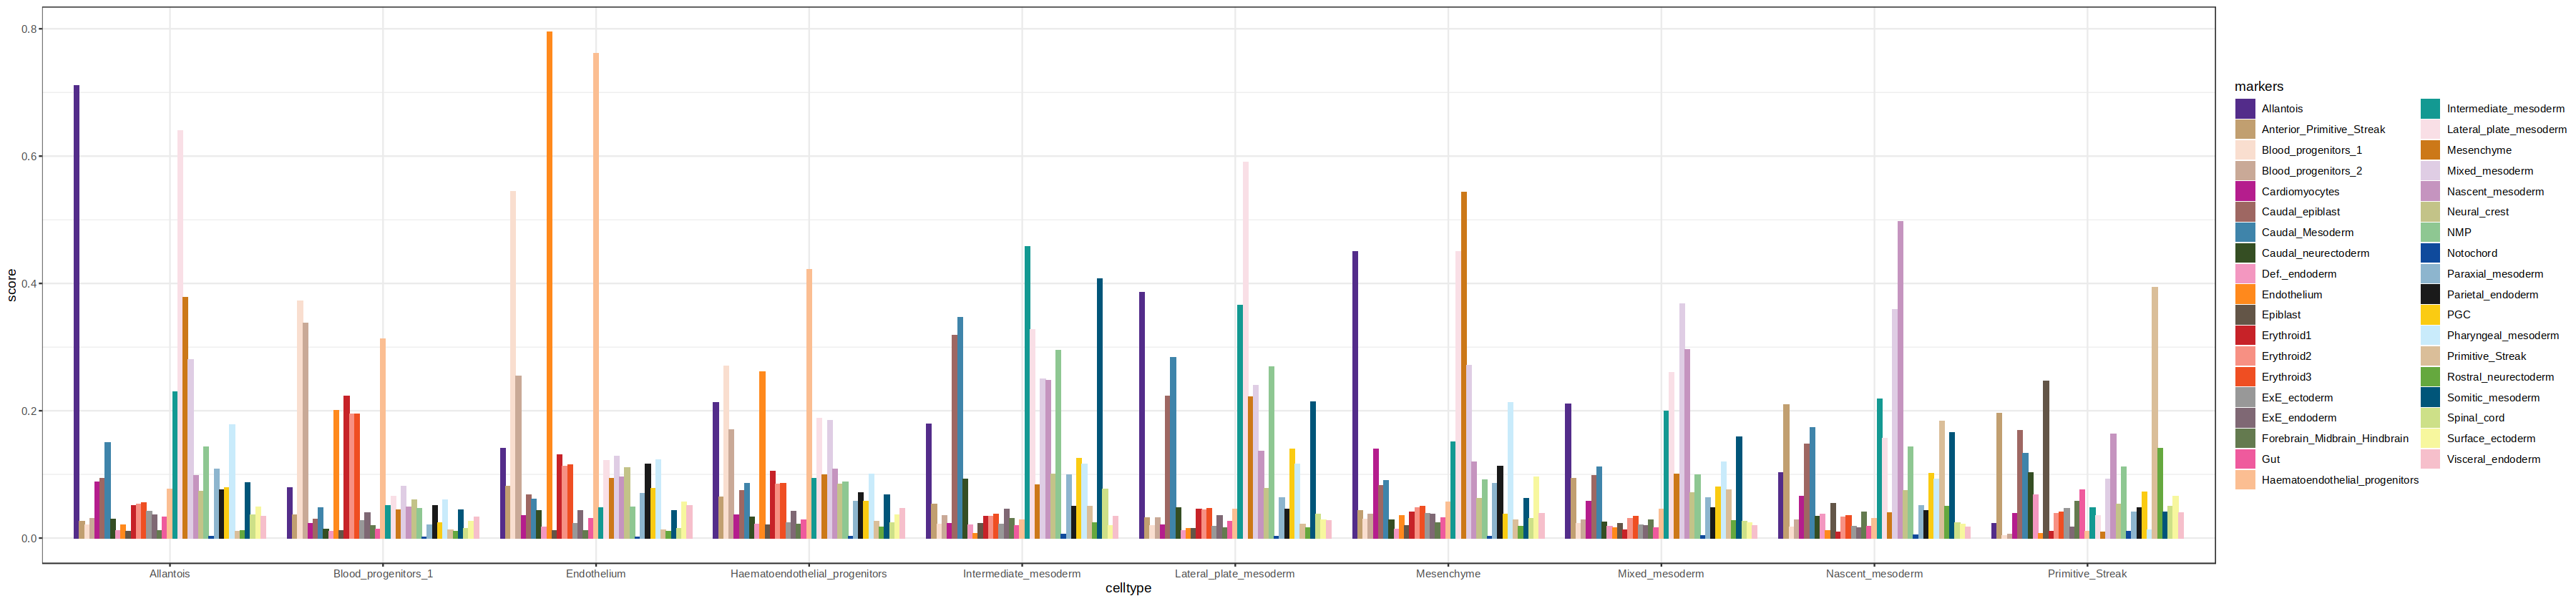

In [123]:
options(repr.plot.width=30)
ggplot(marker_scores, aes(celltype, score, fill=markers)) + 
    geom_bar(stat='identity', position='dodge') + 
    scale_fill_manual(values = c(opts$celltype.colors, opts$celltype_extended.colors)) + 
    theme_bw()

# Determine correlations

In [136]:
library(BiocParallel)
BPPARAM = MulticoreParam(22)

# Get marker gene list
#markers = markers %>%
#    .[FDR<1e-3 & logFC>1.5]
markers_plot = markers[FDR < 0.05][order(-logFC)] %>% .[,head(.SD, 10), by='celltype']
marker_genes = markers_plot[gene %in% rownames(atlas.sce) & gene %in% rownames(rna.sce), gene]

# subset both datasets to marker genes only
atlas_filt = atlas.sce[unique(marker_genes),]
sce_filt = rna.sce[unique(marker_genes),]

# pseudobulk both datasets by celltype
atlas.pb = aggregateAcrossCells(atlas_filt, id=atlas_filt$celltype_updated, statistics="mean", use.assay.type="logcounts", BPPARAM = BPPARAM)
sce.pb = aggregateAcrossCells(sce_filt, id=meta$celltype_v1, statistics="mean", use.assay.type="logcounts", BPPARAM = BPPARAM)



In [137]:
atlas_levels = c('Primitive_Streak', 'Nascent_mesoderm', 'Mixed_mesoderm', 'Haematoendothelial_progenitors', 'Blood_progenitors_1', 'Endothelium', 'Lateral_plate_mesoderm', 'Allantois', 'Mesenchyme')
vitro_levels = c('Primitive_Streak', 'Early_Mes_EOd', 'Early_Mes_EOi', 'HE_Precursor', 'HE', 'Blood_Progenitor', 'Endothelium', 'Posterior_Mes', 'Allantois_Precursor', 'Allantois', 'Mesenchyme')


In [169]:

# Perform pairwise correlation between for all celltypes between the 2 datasets 
celltypes_vitro = colnames(sce.pb)
celltypes_atlas = colnames(atlas.pb)

correlations = mclapply(atlas_levels, function(x){
    # Get atlas counts for the celltype
    atlas_counts = as.vector(logcounts(atlas.pb[,x]))
    
    # Correlate with every celltype in chimera object
    calc_correlations = lapply(celltypes_vitro, function(y){
        vitro_counts = as.vector(logcounts(sce.pb[,y]))
        tmp = data.table(Correlation = cor(atlas_counts, vitro_counts, method='pearson'),
                         atlas = x,
                         vitro = y)
        return(tmp)
    }) %>% rbindlist()
    return(calc_correlations)
}, mc.cores=12) %>% rbindlist() %>% 
    .[,Correlation:=as.numeric(Correlation)] %>% 
    .[,`:=`(atlas=factor(atlas, levels=atlas_levels), vitro=factor(vitro, levels=vitro_levels))]

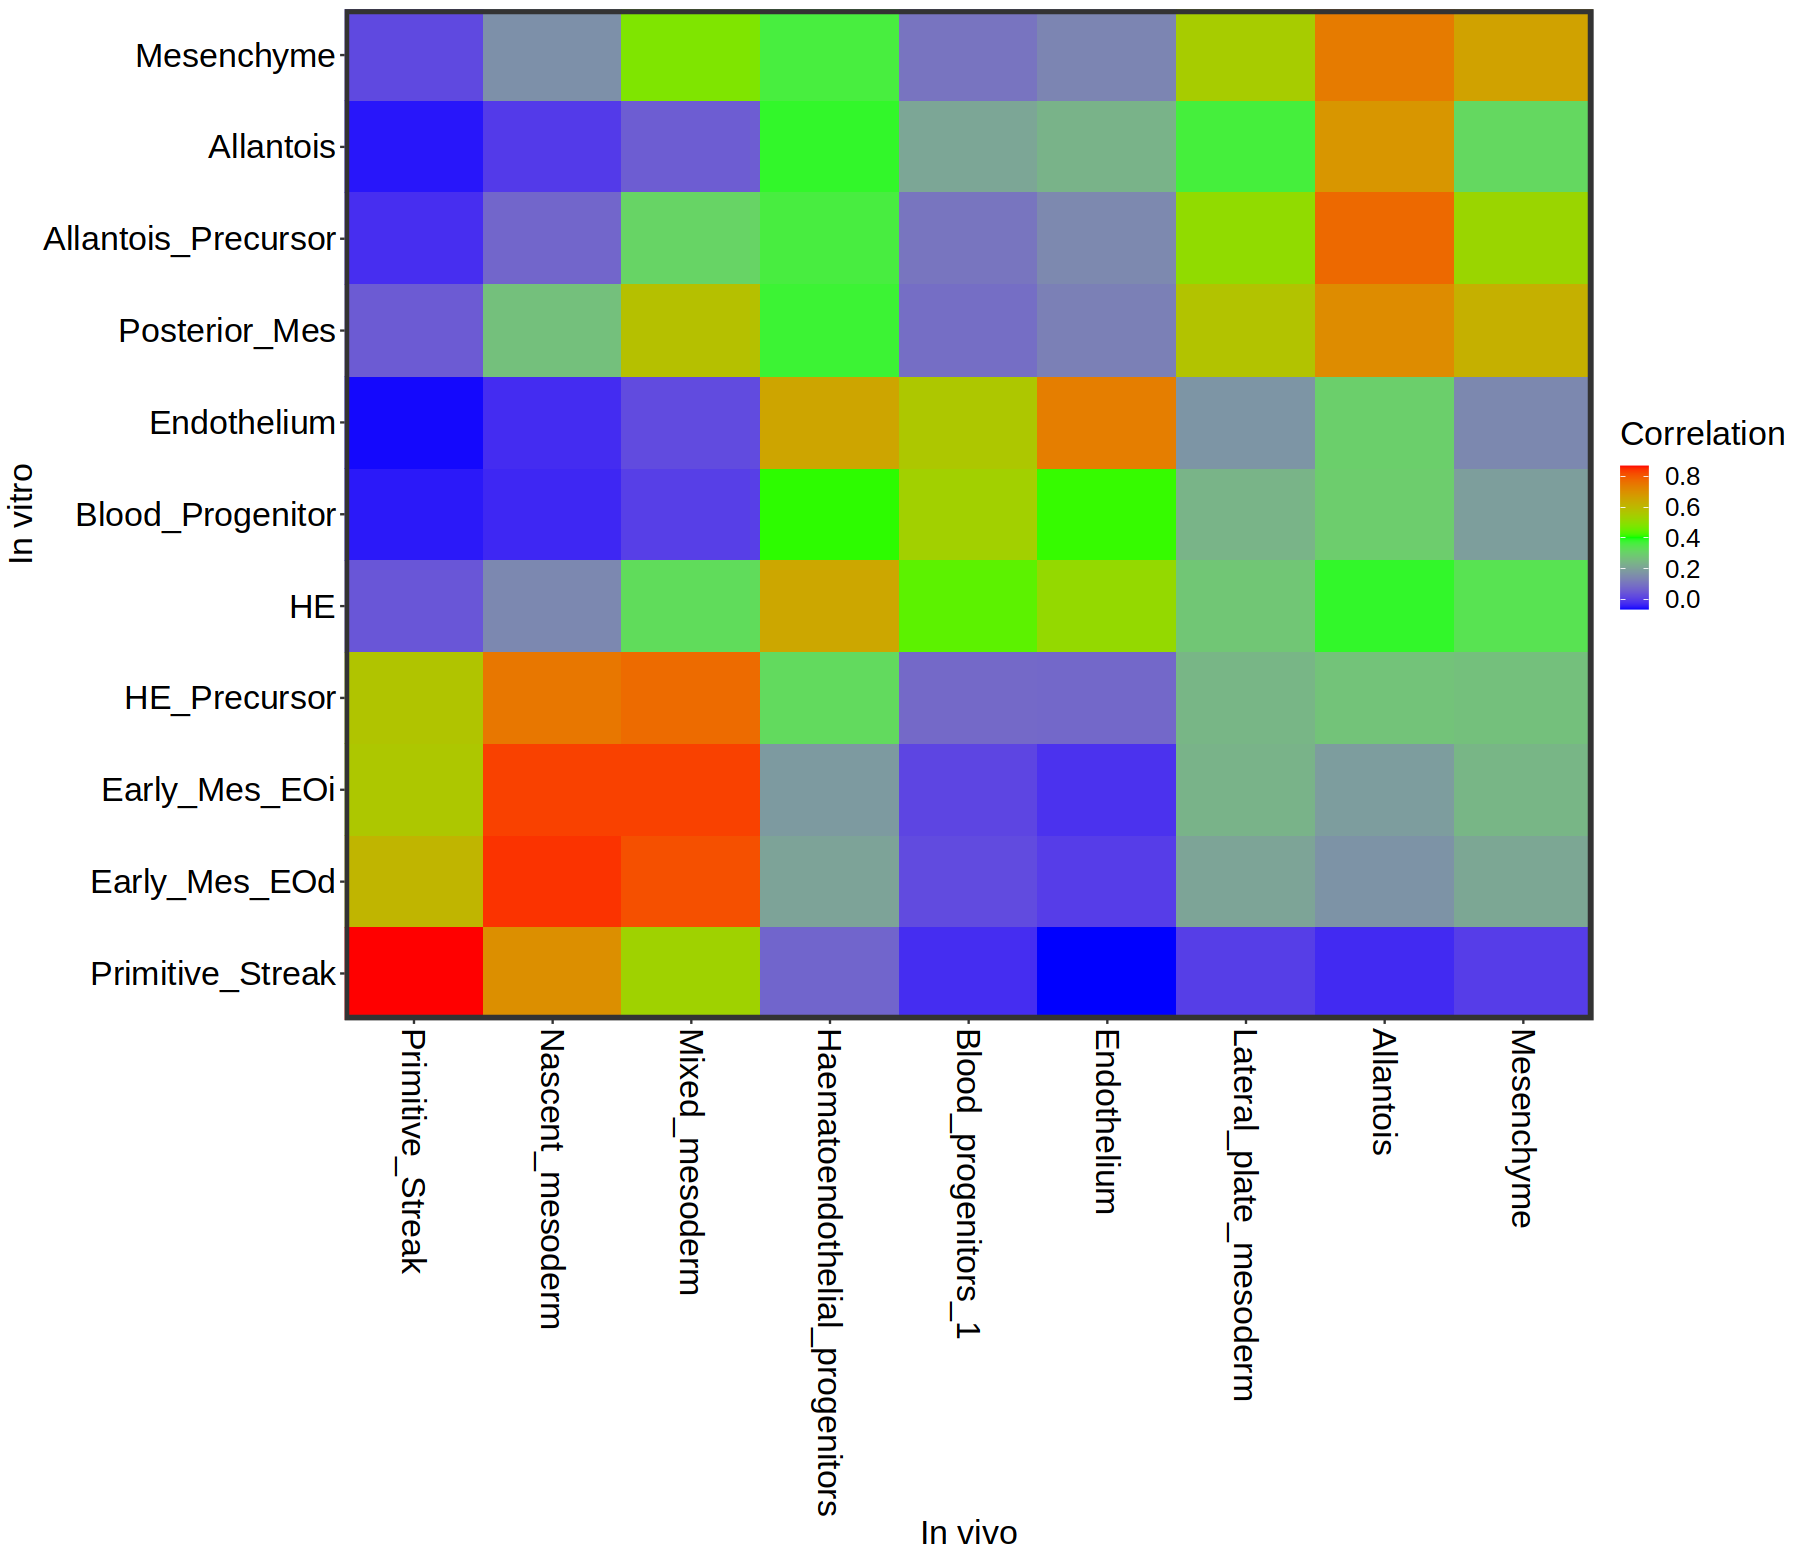

In [170]:
options(repr.plot.width=15, repr.plot.height=13)
p = ggplot(correlations, aes(atlas, vitro, fill=Correlation)) + 
    geom_tile() + 

    #scale_fill_gradientn(colors = c('blue', 'white',  'yellow', 'green', 'red')) + 
    scale_fill_gradientn(colors=rev(rainbow(3))) + 
               #          limits=c(0,1),
               # breaks = c(0, 0.50, 1)) + 
    scale_x_discrete(expand=c(0,0)) + 
    scale_y_discrete(expand=c(0,0)) + 
    xlab('In vivo') + ylab('In vitro') + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5),
          axis.text = element_text(color='black', size = 20),
          axis.title = element_text(size=20),
          legend.text = element_text(size=15),
          legend.title = element_text(size=20),
          panel.border = element_rect(linewidth = 2))

# pdf(file.path(io$basedir, '/results/Suppl/mapping_correlation.pdf'), width=15, height=12)
#     print(p)
# dev.off()
p

In [272]:
options(repr.plot.width=5, repr.plot.height=5)

In [273]:

# Perform pairwise correlation between for all celltypes between the 2 datasets 
celltypes_vitro = colnames(sce.pb)
celltypes_atlas = colnames(atlas.pb)

correlations = mclapply(celltypes_atlas, function(x){
    # Get atlas counts for the celltype
    atlas_counts = as.vector(logcounts(atlas.pb[,x]))
    
    # Correlate with every celltype in chimera object
    counts = lapply(celltypes_vitro, function(y){
        vitro_counts = as.vector(logcounts(sce.pb[,y]))
        tmp = data.table(
                         atlas_ct = x,
                         atlas_counts = atlas_counts,
                         vitro_ct = y,
                         vitro_counts = vitro_counts,
                         gene = rownames(atlas.pb))
        return(tmp)
    }) %>% rbindlist()
    return(counts)
}, mc.cores=12) %>% rbindlist() %>% 
    .[,`:=`(atlas_ct=factor(atlas_ct, levels=celltypes_atlas), vitro_ct=factor(vitro_ct, levels=vitro_levels))]

In [274]:
plot_comparison = function(atlas = 'Allantois', vitro = 'Allantois', top_n = 10){
    tmp = correlations[atlas_ct == atlas & vitro_ct == vitro]
    labels = unique(c(tmp %>% copy() %>% .[order(-atlas_counts)] %>% head(top_n) %>% .$gene,
                       tmp %>% copy() %>% .[order(-vitro_counts)] %>% head(top_n) %>% .$gene))
    labels = tmp[gene %in% labels]
    
    p = ggplot(tmp, aes(atlas_counts, vitro_counts)) + 
            geom_point() + 
            ggrepel::geom_text_repel(data = labels, aes(label = gene)) + 
            ggtitle(paste0('correlation = ', cor(tmp$atlas_counts, tmp$vitro_counts, method='pearson'))) + 
            theme_bw()
    return(p)
}

In [280]:
celltypes_atlas

[1] "Allantois"                      "Anterior_Primitive_Streak"     
 [3] "Blood_progenitors_1"            "Blood_progenitors_2"           
 [5] "Cardiomyocytes"                 "Caudal_epiblast"               
 [7] "Caudal_Mesoderm"                "Caudal_neurectoderm"           
 [9] "Def._endoderm"                  "Endothelium"                   
[11] "Epiblast"                       "Erythroid1"                    
[13] "Erythroid2"                     "Erythroid3"                    
[15] "ExE_ectoderm"                   "ExE_endoderm"                  
[17] "Forebrain_Midbrain_Hindbrain"   "Gut"                           
[19] "Haematoendothelial_progenitors" "Intermediate_mesoderm"         
[21] "Lateral_plate_mesoderm"         "Mesenchyme"                    
[23] "Mixed_mesoderm"                 "Nascent_mesoderm"              
[25] "Neural_crest"                   "NMP"                           
[27] "Notochord"                      "Paraxial_mesoderm"             
[29] "Parietal_endoderm"              "PGC"                           
[31] "Pharyngeal_mesoderm"            "Primitive_Streak"              
[33] "Rostral_neurectoderm"           "Somitic_mesoderm"              
[35] "Spinal_cord"                    "Surface_ectoderm"              
[37] "Visceral_endoderm"

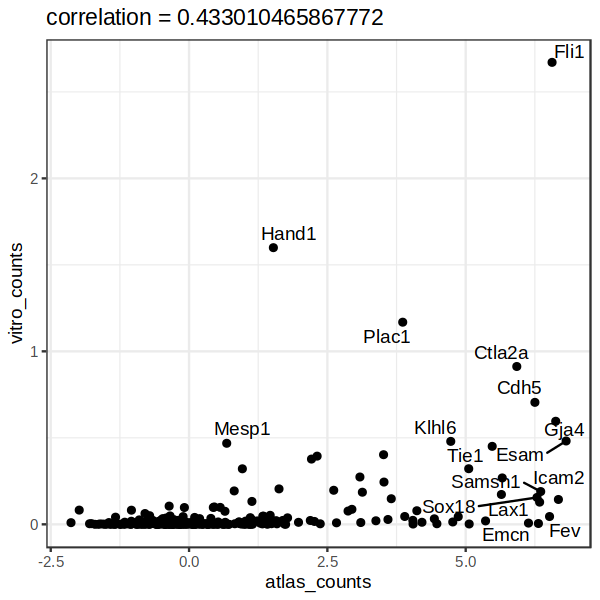

In [281]:
plot_comparison(atlas = 'Haematoendothelial_progenitors', vitro = 'HE')

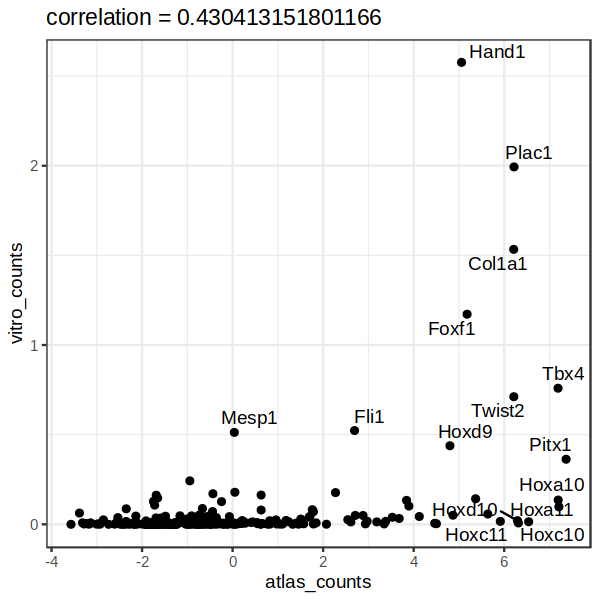

In [279]:
plot_comparison(atlas = 'Allantois', vitro = 'Mesenchyme')

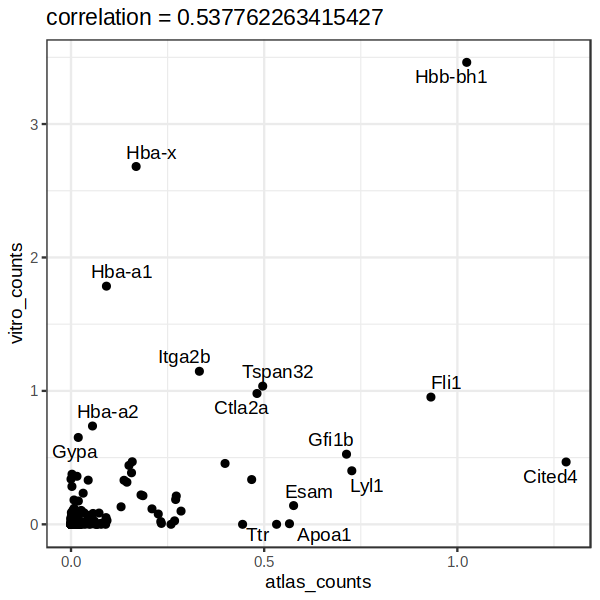

In [179]:
plot_comparison(atlas = 'Blood_progenitors_1', vitro = 'Blood_Progenitor')

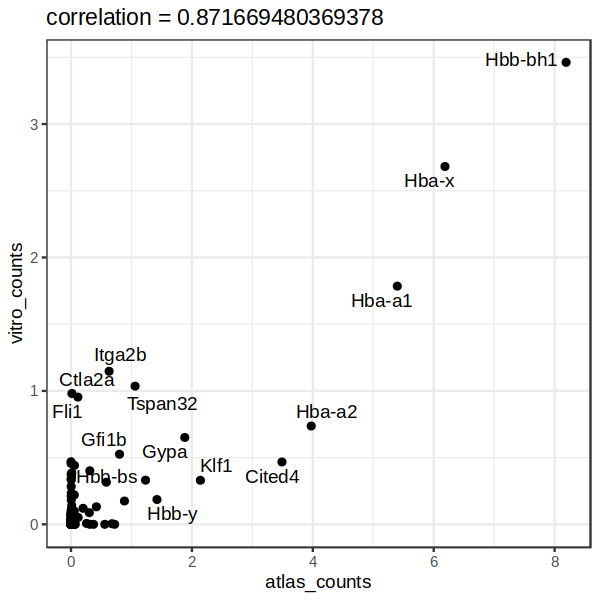

In [207]:
plot_comparison(atlas = 'Erythroid1', vitro = 'Blood_Progenitor')

In [276]:
# Perform pairwise correlation between for all celltypes between the 2 datasets 
celltypes_vitro = colnames(sce.pb)
celltypes_atlas = colnames(atlas.pb)

correlations = mclapply(celltypes_atlas, function(x){
    # Get atlas counts for the celltype
    atlas_counts = markers[celltype == x,][match(rownames(atlas.pb), gene),]
    
    # Correlate with every celltype in chimera object
    counts = lapply(celltypes_vitro, function(y){
        vitro_counts = as.vector(logcounts(sce.pb[,y]))
        tmp = data.table(
                         atlas_ct = x,
                         atlas_counts = atlas_counts$logFC,
                         vitro_ct = y,
                         vitro_counts = vitro_counts,
                         gene = rownames(atlas.pb))
        return(tmp)
    }) %>% rbindlist()
    return(counts)
}, mc.cores=12) %>% rbindlist() %>% 
    .[,`:=`(atlas_ct=factor(atlas_ct, levels=celltypes_atlas), vitro_ct=factor(vitro_ct, levels=vitro_levels))]

In [277]:
plot_comparison = function(atlas = 'Allantois', vitro = 'Allantois', top_n = 10){
    tmp = correlations[atlas_ct == atlas & vitro_ct == vitro]
    labels = unique(c(tmp %>% copy() %>% .[order(-atlas_counts)] %>% head(top_n) %>% .$gene,
                       tmp %>% copy() %>% .[order(-vitro_counts)] %>% head(top_n) %>% .$gene))
    labels = tmp[gene %in% labels]
    
    p = ggplot(tmp, aes(atlas_counts, vitro_counts)) + 
            geom_point() + 
            ggrepel::geom_text_repel(data = labels, aes(label = gene)) + 
            ggtitle(paste0('correlation = ', cor(tmp$atlas_counts, tmp$vitro_counts, method='pearson'))) + 
            theme_bw()
    
    return(p)
}

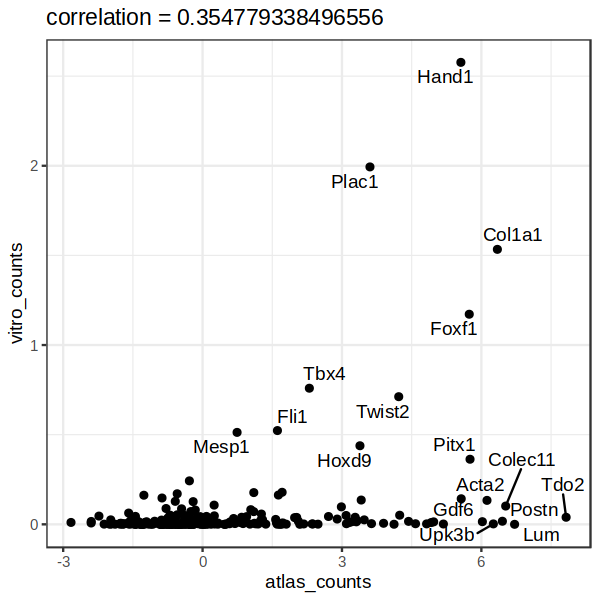

In [278]:
plot_comparison(atlas = 'Mesenchyme', vitro = 'Mesenchyme')

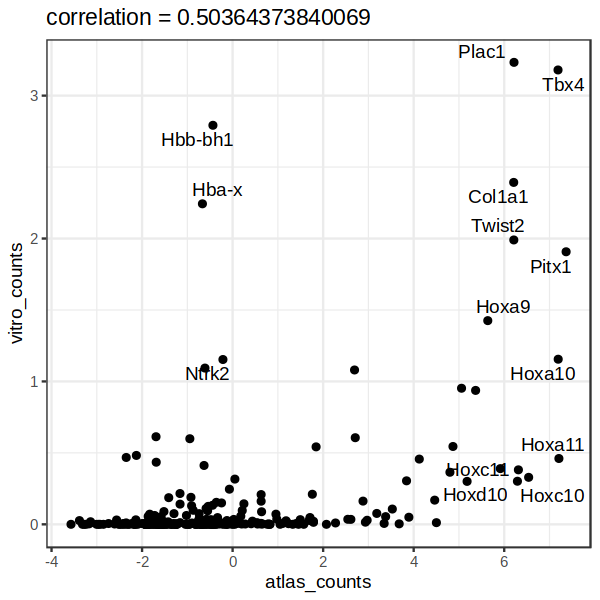

In [218]:
plot_comparison(atlas = 'Allantois', vitro = 'Allantois')

In [221]:
sce.pb$celltype_v1

[1] "Allantois"           "Allantois_Precursor" "Blood_Progenitor"   
 [4] "Early_Mes_EOd"       "Early_Mes_EOi"       "Endothelium"        
 [7] "HE"                  "HE_Precursor"        "Mesenchyme"         
[10] "Posterior_Mes"       "Primitive_Streak"

In [227]:
logcounts(tmp.sce)

,Allantois
Fam183b,0.000000000
Nme9,0.011633791
Noto,0.000000000
Dynlrb2,0.000000000
1110017D15Rik,0.001911012
1700028P14Rik,0.000000000
Meig1,0.035295524
Dnajb13,0.007315020
1700001C02Rik,0.000000000
Cfap161,0.005166106


In [267]:
marker_scores = mclapply(vitro_levels, function(x){
    tmp.sce = sce.pb[,sce.pb$celltype_v1==x]
    score.dt = lapply(atlas_levels, function(y){
            genes = head(markers[celltype==y & FDR < 0.05][order(-logFC)], 50) %>% .$gene
            genes = intersect(genes, rownames(tmp.sce))

            tmp = data.table(celltype = x,
                             markers = y,
                             score = sum(logcounts(tmp.sce[genes,])),
                             ngenes = length(genes))
            return(tmp)
        }) %>% rbindlist()
    return(score.dt)
}, mc.cores=14) %>% rbindlist() %>% 
        .[,`:=`(markers=factor(markers, levels=atlas_levels), celltype=factor(celltype, levels=opts$celltype_levels2))]

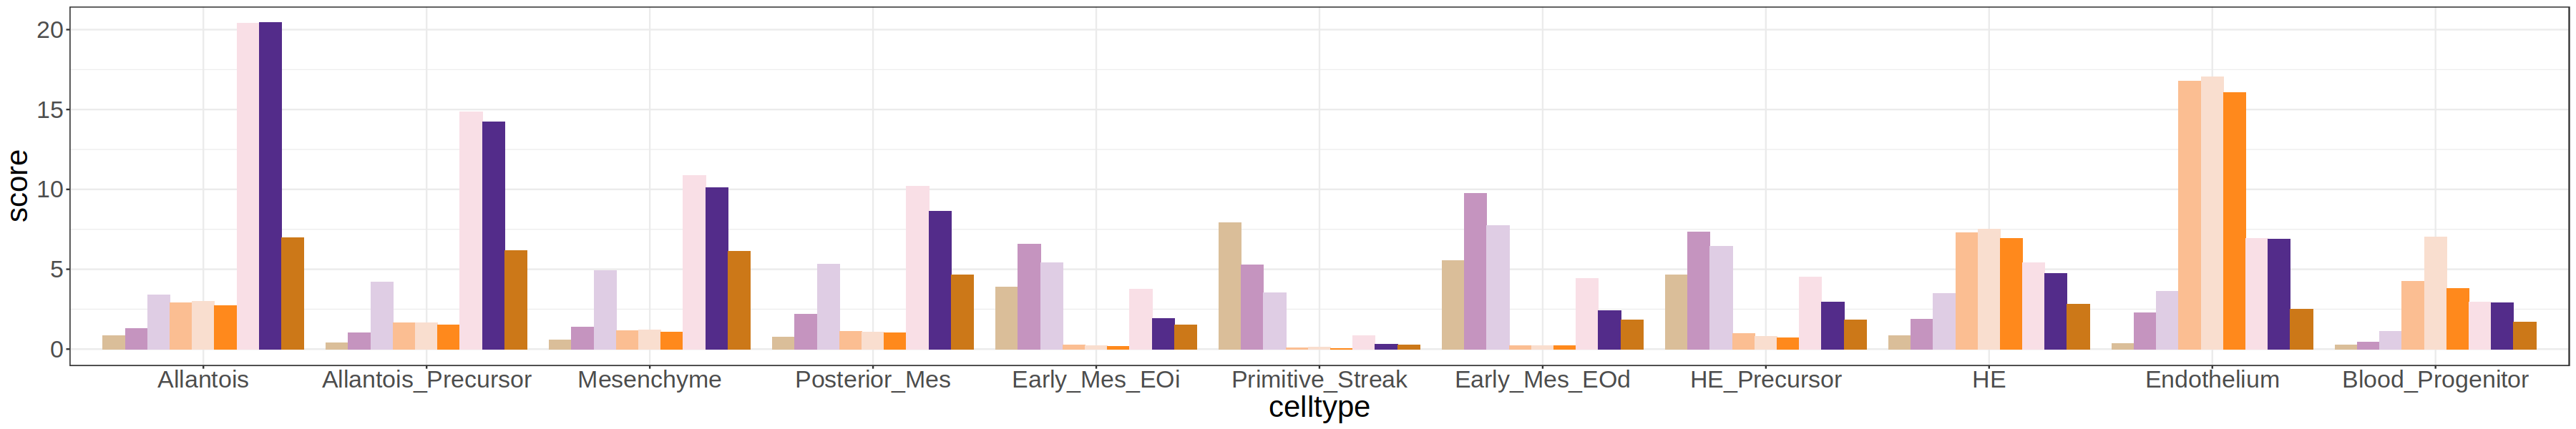

In [268]:
options(repr.plot.width=30)
ggplot(marker_scores, aes(celltype, score, fill=markers)) + 
    geom_bar(stat='identity', position='dodge') + 
    scale_fill_manual(values = c(opts$celltype.colors, opts$celltype_extended.colors)) + 
    theme_bw() + 
    theme(text = element_text(size=25, color='black'),
          legend.position = 'none')